In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set IEEE-friendly plotting aesthetics
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'lines.linewidth': 2.5,
    'legend.fontsize': 12,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight'
})

# Define the path to our results directory
RESULTS_DIR = os.path.join('..', 'results', 'neural3')
DATASET_NAME = 'synthetic' # Change this when running on UCI datasets

In [2]:
methods = ['advi', 'lowrank', 'qmcvi', 'yoasovi', 'bbvi_10', 'bbvi_100', 'bbvi_500', 'bbvi_1000']
results_data = {}

for method in methods:
    filepath = os.path.join(RESULTS_DIR, f"{method}_{DATASET_NAME}_results.pkl")
    try:
        with open(filepath, 'rb') as f:
            results_data[method.upper()] = pickle.load(f)
        print(f"Successfully loaded {method.upper()} data.")
    except FileNotFoundError:
        print(f"Warning: Could not find {filepath}. Have you run the training script yet?")

Successfully loaded ADVI data.
Successfully loaded LOWRANK data.
Successfully loaded QMCVI data.
Successfully loaded YOASOVI data.
Successfully loaded BBVI_10 data.
Successfully loaded BBVI_100 data.
Successfully loaded BBVI_500 data.
Successfully loaded BBVI_1000 data.


In [3]:
summary_records = []

for method, data in results_data.items():
    # Extract the aggregate metrics across all trials
    metrics = data['summary_metrics']
    
    # Calculate means and standard deviations
    elbo_m, elbo_s = np.mean(metrics['elbo']), np.std(metrics['elbo'])
    time_m, time_s = np.mean(metrics['time']), np.std(metrics['time'])
    rmse_m, rmse_s = np.mean(metrics['rmse']), np.std(metrics['rmse'])
    dic_m, dic_s = np.mean(metrics['dic']), np.std(metrics['dic'])
    
    summary_records.append({
        'Method': method,
        'Final ELBO': f"{elbo_m:.2f} ± {elbo_s:.2f}",
        'Total Time (s)': f"{time_m:.2f} ± {time_s:.2f}",
        'Test RMSE': f"{rmse_m:.4f} ± {rmse_s:.4f}",
        'Test DIC': f"{dic_m:.2f} ± {dic_s:.2f}"
    })

summary_df = pd.DataFrame(summary_records).set_index('Method')

print(f"--- Ending Performance Summary ({DATASET_NAME.capitalize()} Data) ---")
display(summary_df)

# Optional: Export to LaTeX format for your paper
# print(summary_df.to_latex())

--- Ending Performance Summary (Synthetic Data) ---


,Final ELBO,Total Time (s),Test RMSE,Test DIC
Method,,,,
ADVI,-1262.91 ± 124.41,16.26 ± 0.98,1.3951 ± 0.1933,501.72 ± 20.79
LOWRANK,-1500.25 ± 71.48,23.94 ± 0.94,1.5728 ± 0.1250,636.31 ± 51.08
QMCVI,-1118.17 ± 28.51,174.72 ± 24.97,1.1784 ± 0.1679,429.74 ± 39.11
YOASOVI,-1196.76 ± 35.28,40.11 ± 9.34,1.4074 ± 0.1555,502.41 ± 17.69
BBVI_10,-8206.10 ± 351.90,975.16 ± 38.89,10.0956 ± 2.0851,1261.96 ± 178.30
BBVI_100,-7766.01 ± 68.19,10516.49 ± 447.17,7.3893 ± 1.3891,896.86 ± 38.50
BBVI_500,-7163.48 ± 67.07,18009.46 ± 5.03,5.0997 ± 0.7603,683.48 ± 34.19
BBVI_1000,-7023.58 ± 35.63,18026.19 ± 18.28,4.2694 ± 0.2289,617.33 ± 4.33


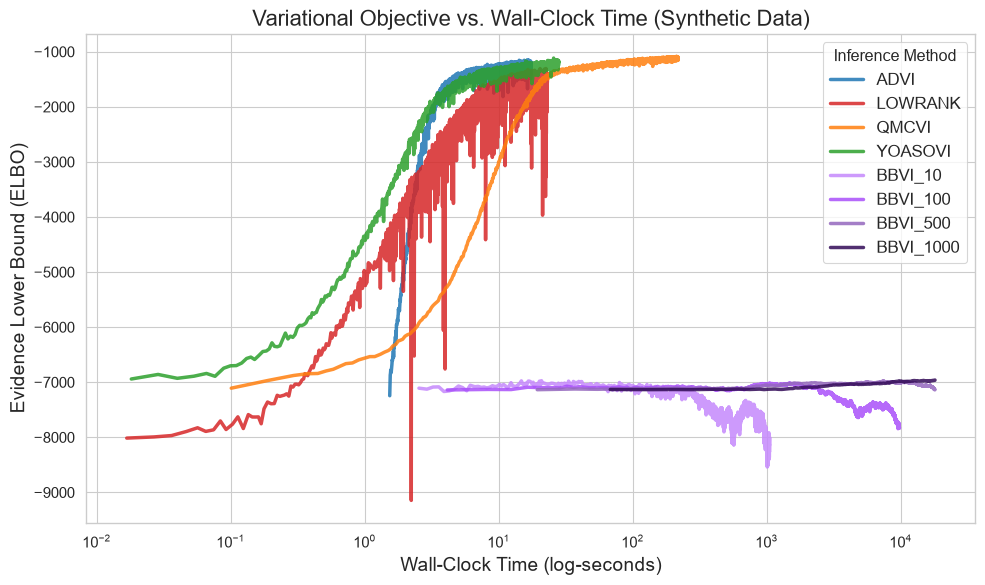

In [4]:
fig, ax = plt.subplots()

# Expanded color palette to include all the new methods
colors = {
    'ADVI': '#1f77b4', 
    'QMCVI': '#ff7f0e', 
    'YOASOVI': '#2ca02c', 
    'LOWRANK': '#d62728', 
    'BBVI_10': '#c588fc',
    'BBVI_100': '#a950fa',
    'BBVI_500': '#9467bd',
    'BBVI_1000': '#320a57'
}

for method, data in results_data.items():
    # Retrieve the step-by-step history from the first trial
    plot_data = data['plot_data']
    
    # .get() provides a fallback default color just in case a new method name is used
    c = colors.get(method.upper(), None)
    
    ax.plot(plot_data['time'], plot_data['elbo'], label=method, color=c, alpha=0.85)
    ax.set_xscale('log')

ax.set_title(f'Variational Objective vs. Wall-Clock Time ({DATASET_NAME.capitalize()} Data)')
ax.set_xlabel('Wall-Clock Time (log-seconds)')
ax.set_ylabel('Evidence Lower Bound (ELBO)')
ax.legend(title='Inference Method')

# Depending on the data, ELBO values might be massively negative early on.
# You can uncomment the line below to set a custom y-limit to zoom in on the convergence area.
# ax.set_ylim([-5000, max([max(d['plot_data']['elbo']) for d in results_data.values()]) + 100])

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, f'elbo_vs_time_{DATASET_NAME}.png'))
plt.show()

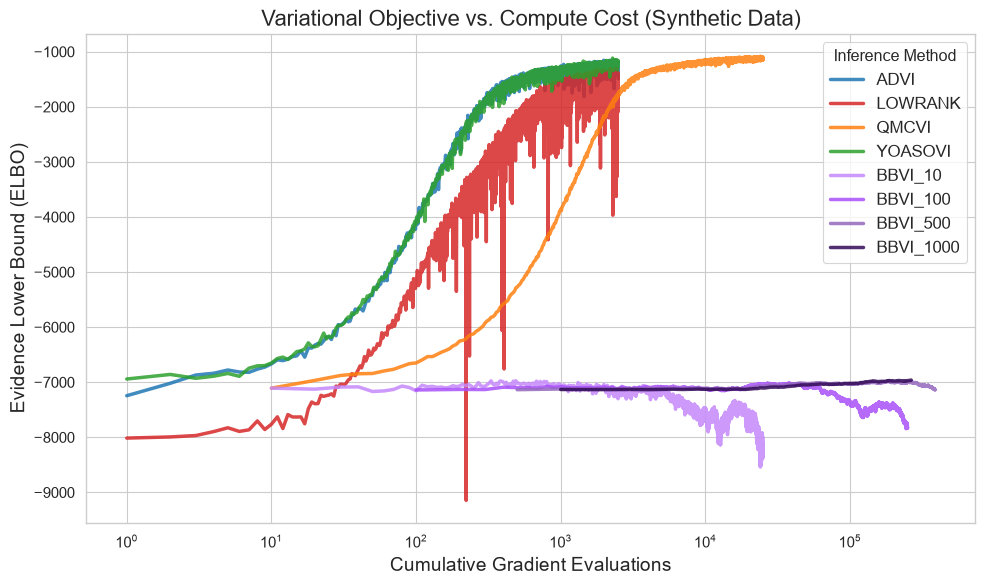

In [5]:
fig, ax = plt.subplots()

for method, data in results_data.items():
    plot_data = data['plot_data']
    c = colors.get(method.upper(), None)
    
    ax.plot(plot_data['evals'], plot_data['elbo'], label=method, color=c, alpha=0.85)

ax.set_title(f'Variational Objective vs. Compute Cost ({DATASET_NAME.capitalize()} Data)')
ax.set_xlabel('Cumulative Gradient Evaluations')
ax.set_ylabel('Evidence Lower Bound (ELBO)')
ax.legend(title='Inference Method')

# Because QMCVI and BBVI_500 do many evaluations per step, 
# a log scale on the X-axis is highly recommended to make this readable.
ax.set_xscale('log')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, f'elbo_vs_evals_{DATASET_NAME}.png'))
plt.show()

In [6]:
RESULTS_DIR = os.path.join('..', 'results', 'neural4')

methods = ['advi', 'lowrank', 'qmcvi', 'yoasovi', 'bbvi_10', 'bbvi_100', 'bbvi_500', 'bbvi_1000']
results_data = {}

for method in methods:
    filepath = os.path.join(RESULTS_DIR, f"{method}_{DATASET_NAME}_results.pkl")
    try:
        with open(filepath, 'rb') as f:
            results_data[method.upper()] = pickle.load(f)
        print(f"Successfully loaded {method.upper()} data.")
    except FileNotFoundError:
        print(f"Warning: Could not find {filepath}. Have you run the training script yet?")

Successfully loaded ADVI data.
Successfully loaded LOWRANK data.
Successfully loaded QMCVI data.
Successfully loaded YOASOVI data.


In [10]:
summary_records = []

for method, data in results_data.items():
    metrics = data['summary_metrics']
    
    elbo_m, elbo_s = np.mean(metrics['elbo']), np.std(metrics['elbo'])
    time_m, time_s = np.mean(metrics['time']), np.std(metrics['time'])
    rmse_m, rmse_s = np.mean(metrics['rmse']), np.std(metrics['rmse'])
    dic_m, dic_s = np.mean(metrics['dic']), np.std(metrics['dic'])
    
    summary_records.append({
        'Method': method,
        'Final ELBO': f"{elbo_m:.2f} ± {elbo_s:.2f}",
        'Total Time (s)': f"{time_m:.2f} ± {time_s:.2f}",
        'Test RMSE': f"{rmse_m:.4f} ± {rmse_s:.4f}",
        'Test DIC': f"{dic_m:.2f} ± {dic_s:.2f}"
    })

summary_df = pd.DataFrame(summary_records).set_index('Method')

print(f"--- Ending Performance Summary ({DATASET_NAME.capitalize()} Data) ---")
display(summary_df)

# Optional: Export to LaTeX format for your paper
# print(summary_df.to_latex())

--- Ending Performance Summary (Synthetic Data) ---


,Final ELBO,Total Time (s),Test RMSE,Test DIC
Method,,,,
ADVI,-1301.24 ± 15.24,33.80 ± 2.49,2.5269 ± 0.6181,493.31 ± 35.52
LOWRANK,-1869.91 ± 191.04,46.04 ± 0.11,2.2480 ± 0.7140,723.62 ± 22.10
QMCVI,-1182.27 ± 32.57,312.57 ± 21.11,1.1950 ± 0.0336,348.73 ± 57.77
YOASOVI,-1304.69 ± 43.93,57.32 ± 0.32,2.4728 ± 0.5648,477.41 ± 42.28


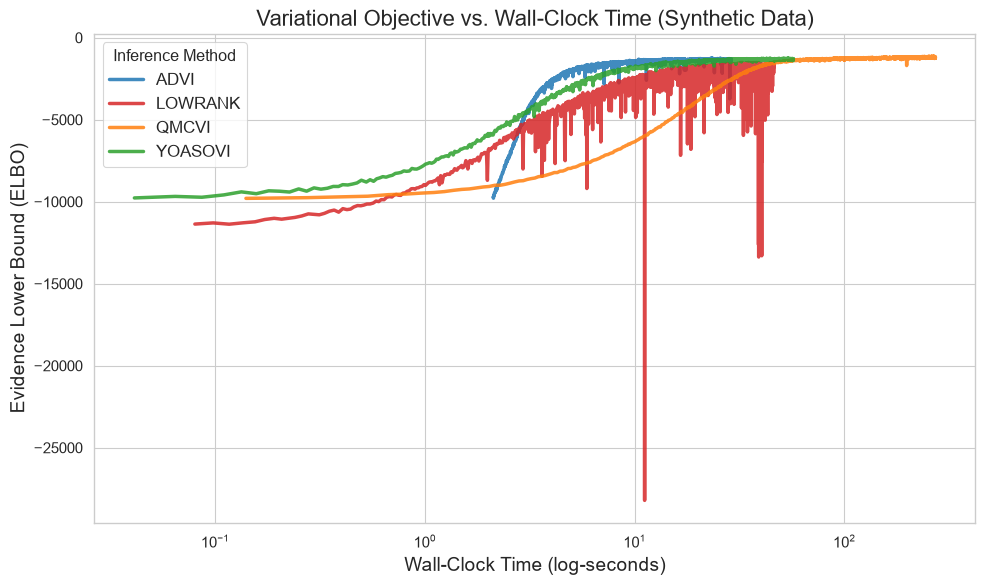

In [11]:
fig, ax = plt.subplots()

colors = {
    'ADVI': '#1f77b4', 
    'QMCVI': '#ff7f0e', 
    'YOASOVI': '#2ca02c', 
    'LOWRANK': '#d62728', 
    'BBVI_10': '#c588fc',
    'BBVI_100': '#a950fa',
    'BBVI_500': '#9467bd',
    'BBVI_1000': '#320a57'
}

for method, data in results_data.items():
    # Retrieve the step-by-step history from the first trial
    plot_data = data['plot_data']
    
    # .get() provides a fallback default color just in case a new method name is used
    c = colors.get(method.upper(), None)
    
    ax.plot(plot_data['time'], plot_data['elbo'], label=method, color=c, alpha=0.85)
    ax.set_xscale('log')

ax.set_title(f'Variational Objective vs. Wall-Clock Time ({DATASET_NAME.capitalize()} Data)')
ax.set_xlabel('Wall-Clock Time (log-seconds)')
ax.set_ylabel('Evidence Lower Bound (ELBO)')
ax.legend(title='Inference Method')

# Depending on the data, ELBO values might be massively negative early on.
# You can uncomment the line below to set a custom y-limit to zoom in on the convergence area.
# ax.set_ylim([-5000, max([max(d['plot_data']['elbo']) for d in results_data.values()]) + 100])

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, f'elbo_vs_time_{DATASET_NAME}.png'))
plt.show()

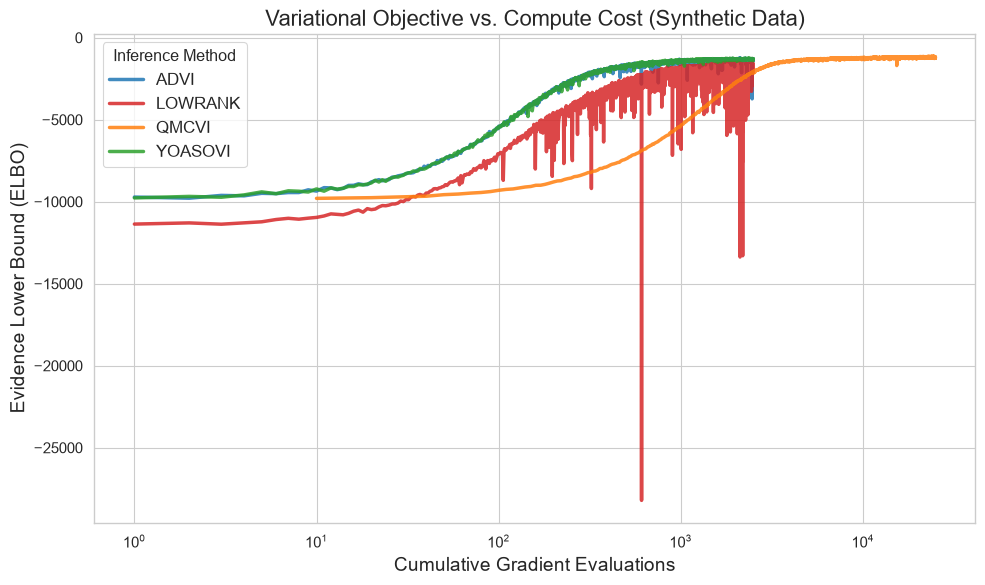

In [9]:
fig, ax = plt.subplots()

for method, data in results_data.items():
    plot_data = data['plot_data']
    c = colors.get(method.upper(), None)
    
    ax.plot(plot_data['evals'], plot_data['elbo'], label=method, color=c, alpha=0.85)

ax.set_title(f'Variational Objective vs. Compute Cost ({DATASET_NAME.capitalize()} Data)')
ax.set_xlabel('Cumulative Gradient Evaluations')
ax.set_ylabel('Evidence Lower Bound (ELBO)')
ax.legend(title='Inference Method')

# Because QMCVI and BBVI_500 do many evaluations per step, 
# a log scale on the X-axis is highly recommended to make this readable.
ax.set_xscale('log')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, f'elbo_vs_evals_{DATASET_NAME}.png'))
plt.show()